In [1]:
from doclayout_yolo import YOLOv10
from dsa.constants import ROOT

/home/ajd/miniconda3/envs/data-snapshot/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the pre-trained model
model = YOLOv10(ROOT / "models/doclayout_yolo_docstructbench_imgsz1024.pt")

# Perform prediction
# IMG_PATH = "../labelstudio_data/dataset_spec/jordanhaus2015finalreport-2.pdf_p004.png"
IMG_PATH = ROOT / "data/pages_cache/analyse_environnement_de_protection_des_regions_de_segou_san_v2_final.pdf_p002.png"
res = model.predict(
    IMG_PATH,   # Image to predict
    imgsz=1024,        # Prediction image size
    conf=0.2,          # Confidence threshold
    device="cpu"    # Device to use (e.g., 'cuda:0' or 'cpu')
)
res


image 1/1 /home/ajd/data-snapshot-annotation/data/pages_cache/analyse_environnement_de_protection_des_regions_de_segou_san_v2_final.pdf_p002.png: 1024x800 2 titles, 4 plain texts, 2 abandons, 2 figures, 1242.6ms
Speed: 6.5ms preprocess, 1242.6ms inference, 1.4ms postprocess per image at shape (1, 3, 1024, 800)


[doclayout_yolo.engine.results.Results object with attributes:
 
 boxes: doclayout_yolo.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'title', 1: 'plain text', 2: 'abandon', 3: 'figure', 4: 'figure_caption', 5: 'table', 6: 'table_caption', 7: 'table_footnote', 8: 'isolate_formula', 9: 'formula_caption'}
 obb: None
 orig_img: array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        ...,
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255]

In [3]:
res[0].names

{0: 'title',
 1: 'plain text',
 2: 'abandon',
 3: 'figure',
 4: 'figure_caption',
 5: 'table',
 6: 'table_caption',
 7: 'table_footnote',
 8: 'isolate_formula',
 9: 'formula_caption'}

In [4]:
res[0].boxes

doclayout_yolo.engine.results.Boxes object with attributes:

cls: tensor([1., 1., 1., 3., 3., 0., 1., 2., 0., 2.])
conf: tensor([0.9839, 0.9818, 0.9666, 0.9497, 0.9446, 0.9338, 0.9075, 0.8737, 0.8524, 0.8497])
data: tensor([[2.9695e+02, 5.3320e+02, 2.2595e+03, 9.1480e+02, 9.8394e-01, 1.0000e+00],
        [2.9537e+02, 1.6607e+03, 2.2581e+03, 2.0416e+03, 9.8179e-01, 1.0000e+00],
        [2.9585e+02, 2.6773e+03, 2.2585e+03, 2.8639e+03, 9.6658e-01, 1.0000e+00],
        [3.0418e+02, 9.7119e+02, 2.2392e+03, 1.5855e+03, 9.4973e-01, 3.0000e+00],
        [3.0214e+02, 2.1010e+03, 2.1172e+03, 2.6078e+03, 9.4459e-01, 3.0000e+00],
        [2.9766e+02, 4.2289e+02, 9.7084e+02, 4.7637e+02, 9.3380e-01, 0.0000e+00],
        [3.8137e+02, 2.9285e+03, 2.2426e+03, 2.9874e+03, 9.0754e-01, 1.0000e+00],
        [1.3757e+01, 4.6459e+01, 1.0377e+03, 2.8397e+02, 8.7370e-01, 2.0000e+00],
        [4.7608e+02, 3.0564e+02, 1.3251e+03, 3.6023e+02, 8.5240e-01, 0.0000e+00],
        [2.2229e+03, 3.1025e+03, 2.2534e+03, 3

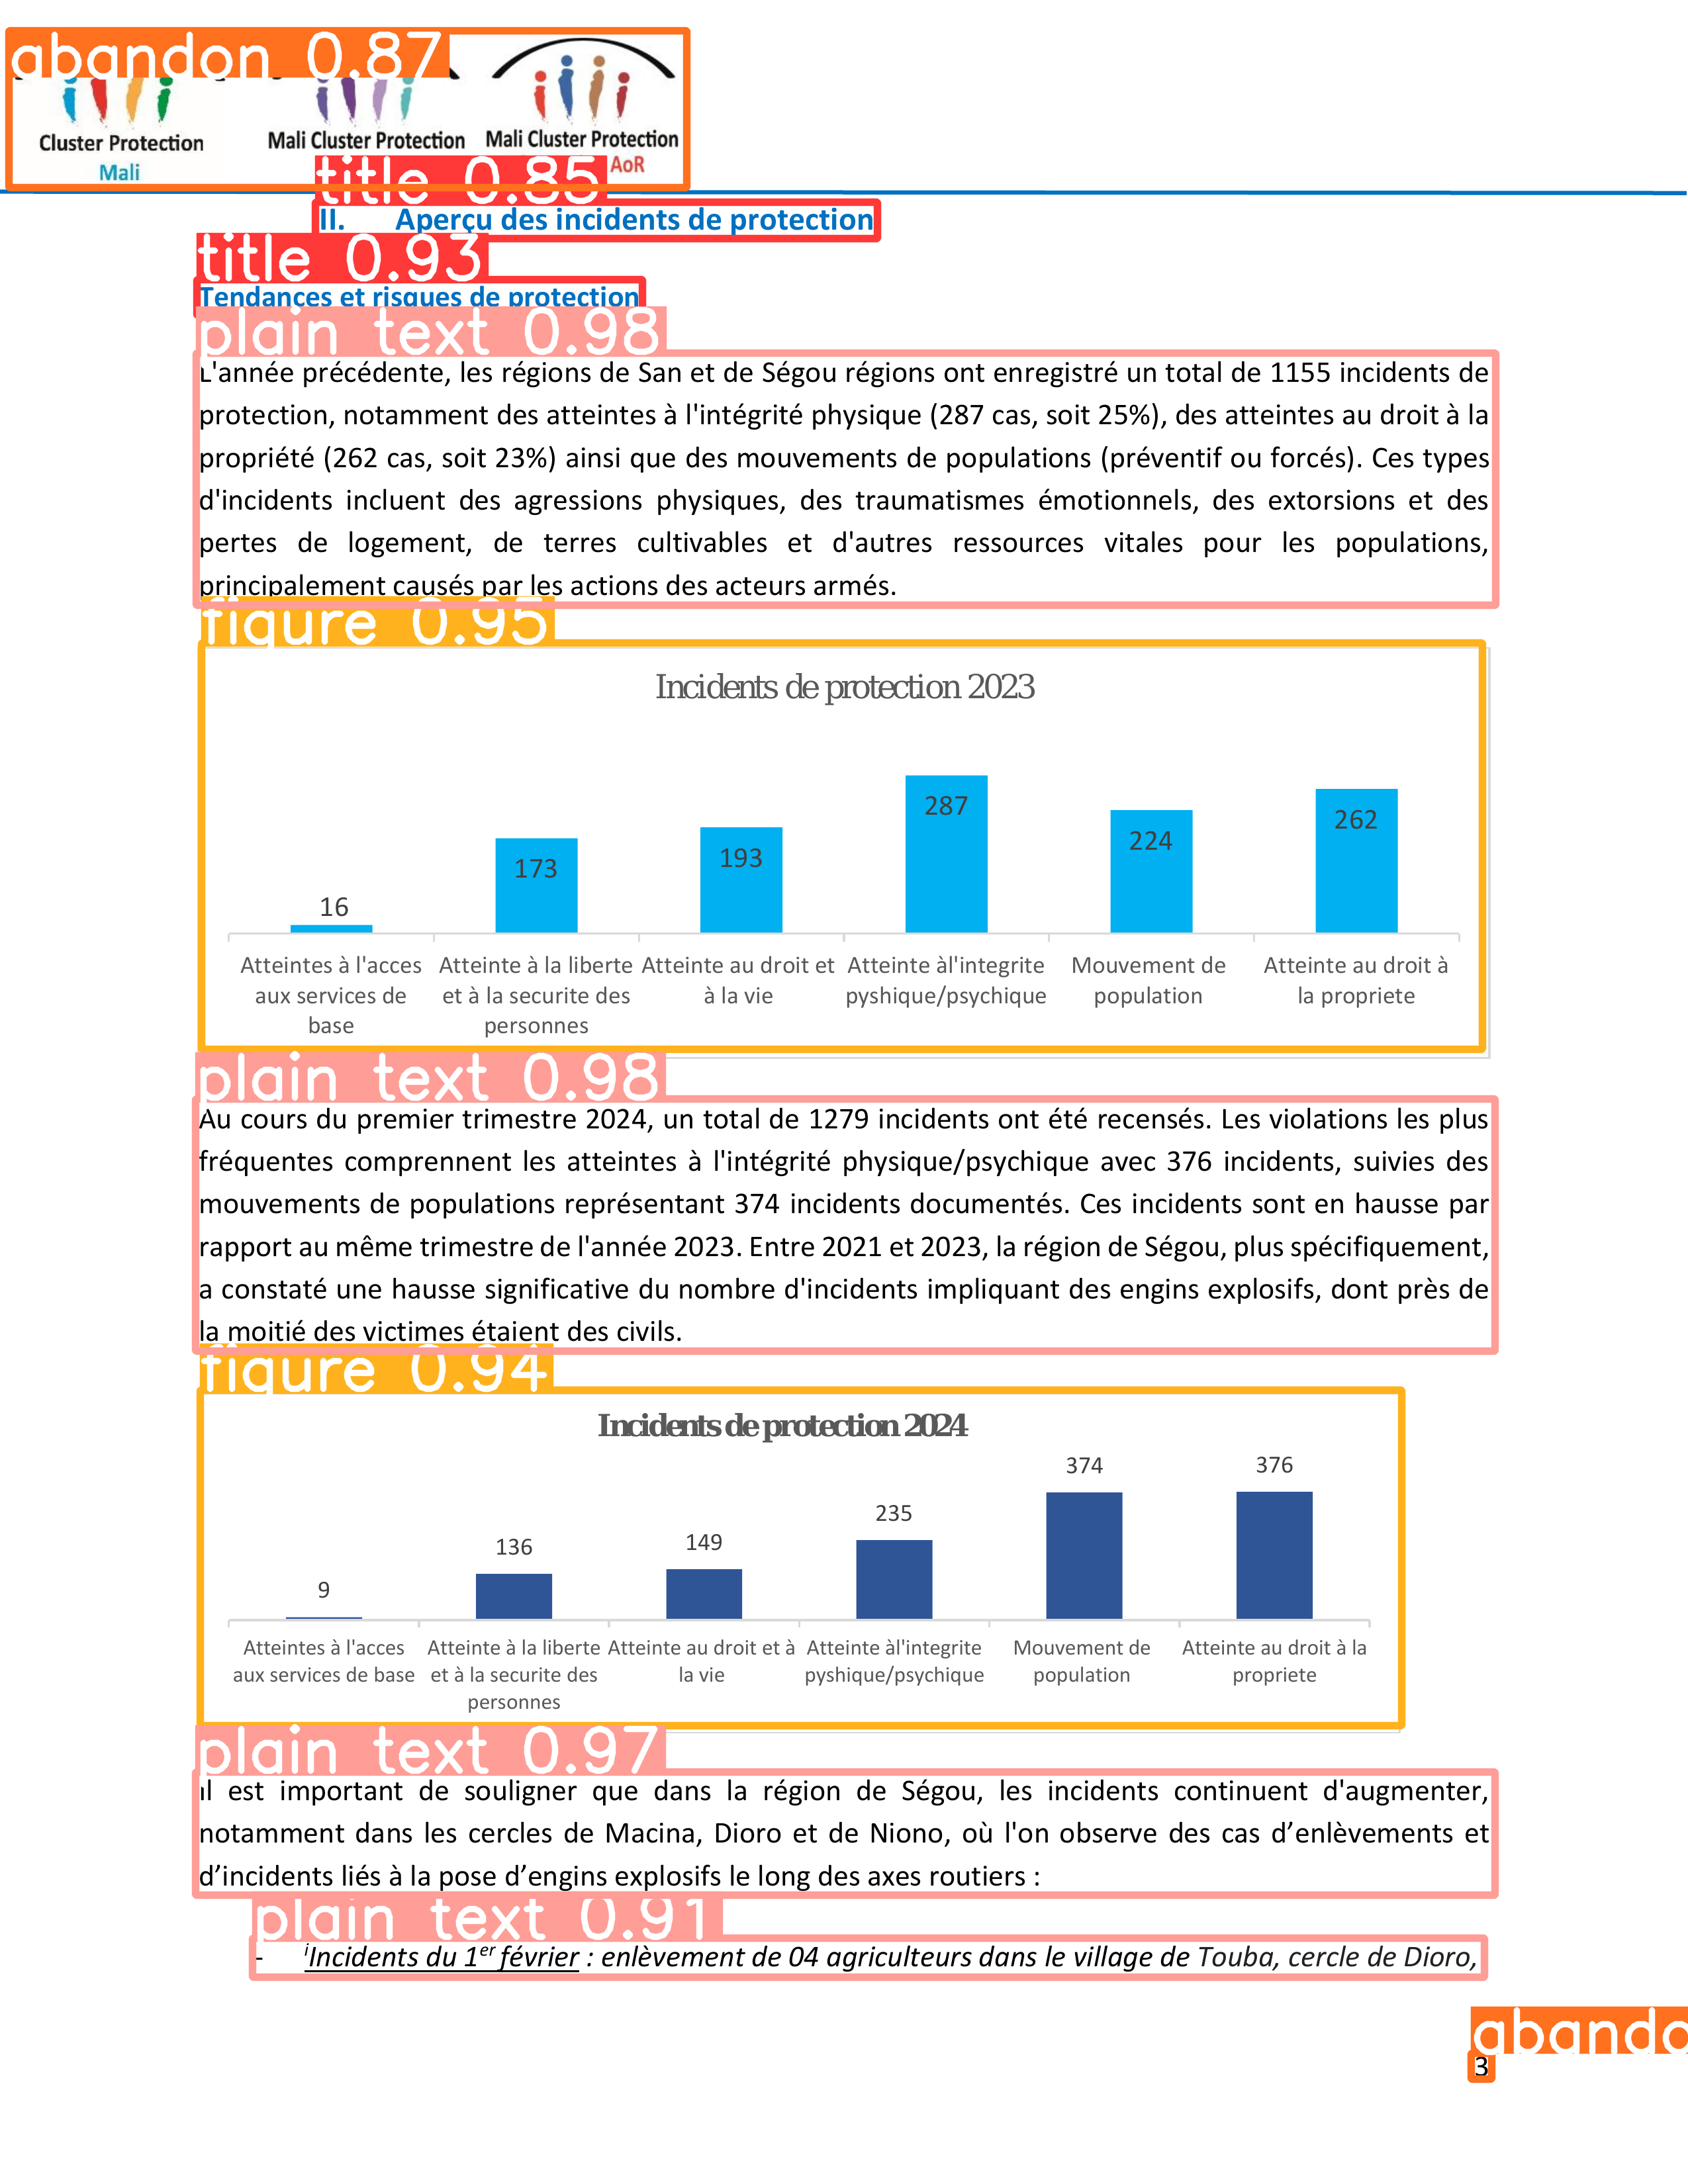

In [5]:
res[0].show()

In [6]:
# # Annotate and save the result
# import cv2
# annotated_frame = det_res[0].plot(pil=True, line_width=5, font_size=20)
# cv2.imwrite("result.jpg", annotated_frame)